# Phase Recovery v12  
## Quantum \( \psi(x) \) version: probability + measurement + AI

This notebook translates the phase-recovery story into a **quantum-style wavefunction notebook**.

## Main idea

In optics, you worked with a complex field \(E\) and measured intensity:

$
I = |E|^2
$

In quantum mechanics, the analogous object is the wavefunction $ \psi $, and the measurable quantity is probability density:

$
P(x)=|\psi(x)|^2
$

So the central structure is the same:

```text
hidden complex wave
→ measurable magnitude-squared quantity
→ inverse problem if phase is unknown
```

This notebook connects:

- wavefunction formalism
- probability density
- momentum-space Fourier transform
- position and momentum measurement
- expectation values
- a small AI inverse model
- a PINN-style quantum reconstruction idea


## Quantum formalism

A normalized wavefunction satisfies:

$
\int |\psi(x)|^2 \, dx = 1
$

The position-space probability density is:

$
P_x(x)=|\psi(x)|^2
$

The momentum-space wavefunction is the Fourier transform:

$
\phi(k)=\mathcal{F}\{\psi(x)\}
$

and the momentum-space probability density is:

$
P_k(k)=|\phi(k)|^2
$

Expectation values are:

$
\langle x \rangle = \int x |\psi(x)|^2 \, dx
$

$
\langle p \rangle = \int \psi^*(x)\left(-i\hbar \frac{d}{dx}\right)\psi(x)\, dx
$


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

plt.rcParams["figure.figsize"] = (8.5, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

GLOBAL_SEED = 7
rng = np.random.default_rng(GLOBAL_SEED)

print("NumPy:", np.__version__)
print("SymPy:", sp.__version__)
print("Torch available:", TORCH_AVAILABLE)
if TORCH_AVAILABLE:
    print("Torch:", torch.__version__)


NumPy: 2.3.5
SymPy: 1.14.0
Torch available: True
Torch: 2.10.0+cpu


## Part A — SymPy formalism


In [2]:
x = sp.symbols('x', real=True)
hbar = sp.symbols('hbar', positive=True, real=True)

A = sp.Function('A')
theta = sp.Function('theta')

psi = A(x) * sp.exp(sp.I * theta(x))
P = sp.simplify(sp.conjugate(psi) * psi)

print("psi(x) =")
sp.pprint(psi)

print("\nProbability density |psi(x)|^2 =")
sp.pprint(P)

p_op_psi = sp.simplify(-sp.I * hbar * sp.diff(psi, x))
print("\nMomentum operator on psi:")
sp.pprint(p_op_psi)


psi(x) =
      ⅈ⋅θ(x)
A(x)⋅ℯ      

Probability density |psi(x)|^2 =
        ⎛       ____⎞     
      ⅈ⋅⎝θ(x) - θ(x)⎠ ____
A(x)⋅ℯ               ⋅A(x)

Momentum operator on psi:
  ⎛     d            d       ⎞  ⅈ⋅θ(x)
h̅⋅⎜A(x)⋅──(θ(x)) - ⅈ⋅──(A(x))⎟⋅ℯ      
  ⎝     dx           dx      ⎠        


## Part B — Numerical quantum wavefunctions


In [3]:
HBAR = 1.0

N = 2**12
x_max = 20.0
x_grid = np.linspace(-x_max, x_max, N)
dx = x_grid[1] - x_grid[0]

k_grid = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, d=dx))

def fftc(x):
    return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))

def ifftc(X):
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))

def normalize_wavefunction(psi, x):
    norm = np.sqrt(np.trapezoid(np.abs(psi)**2, x))
    return psi / max(norm, 1e-14)

def probability_density(psi):
    return np.abs(psi) ** 2

def normalize_density(rho, grid):
    area = np.trapezoid(np.maximum(rho, 0.0), grid)
    return np.maximum(rho, 0.0) / max(area, 1e-14)

print("dx =", dx)
print("x range =", (x_grid[0], x_grid[-1]))
print("k range =", (k_grid[0], k_grid[-1]))


dx = 0.009768009768009733
x range = (np.float64(-20.0), np.float64(20.0))
k range = (np.float64(-321.6205479112562), np.float64(321.4635066280964))


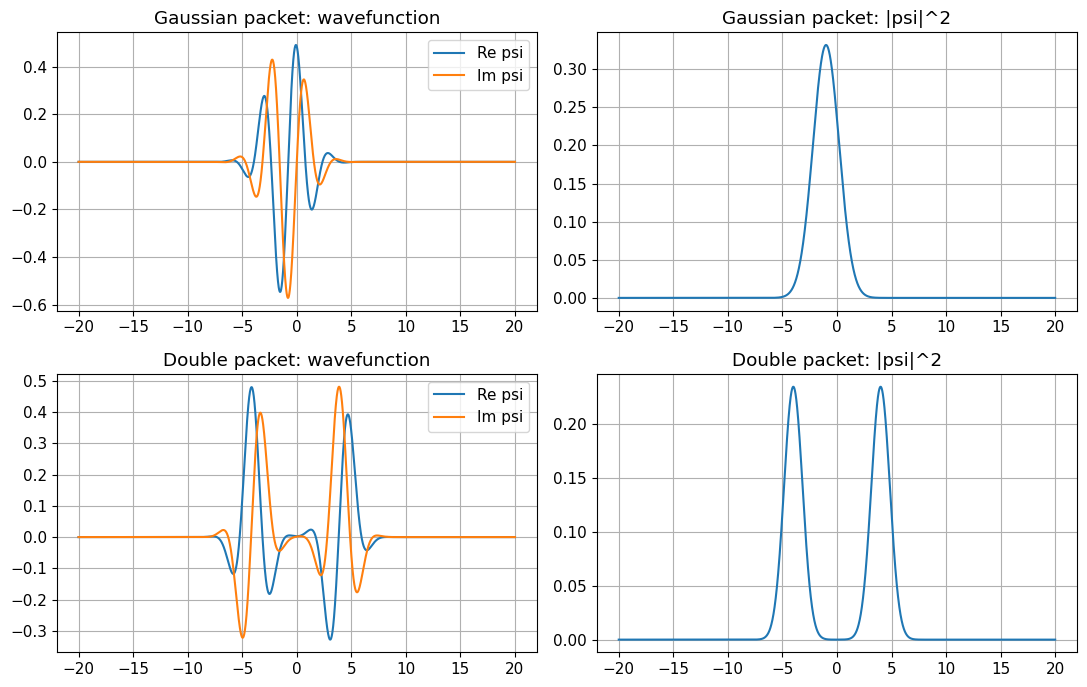

In [4]:
def gaussian_wavepacket(x, x0=0.0, sigma=1.5, k0=2.5, phase_offset=0.0):
    envelope = np.exp(-0.5 * ((x - x0) / sigma) ** 2)
    phase = np.exp(1j * (k0 * x + phase_offset))
    psi = envelope * phase
    return normalize_wavefunction(psi, x)

def double_gaussian_superposition(x, x1=-4.0, x2=4.0, sigma=1.2, k1=1.5, k2=-1.5, rel_phase=0.0):
    psi1 = np.exp(-0.5 * ((x - x1) / sigma) ** 2) * np.exp(1j * k1 * x)
    psi2 = np.exp(-0.5 * ((x - x2) / sigma) ** 2) * np.exp(1j * (k2 * x + rel_phase))
    psi = psi1 + psi2
    return normalize_wavefunction(psi, x)

psi_gauss = gaussian_wavepacket(x_grid, x0=-1.0, sigma=1.7, k0=2.0)
psi_double = double_gaussian_superposition(x_grid, rel_phase=np.pi / 3)

fig, axs = plt.subplots(2, 2, figsize=(11, 7))
axs[0, 0].plot(x_grid, np.real(psi_gauss), label="Re psi")
axs[0, 0].plot(x_grid, np.imag(psi_gauss), label="Im psi")
axs[0, 0].set_title("Gaussian packet: wavefunction")
axs[0, 0].legend()

axs[0, 1].plot(x_grid, probability_density(psi_gauss))
axs[0, 1].set_title("Gaussian packet: |psi|^2")

axs[1, 0].plot(x_grid, np.real(psi_double), label="Re psi")
axs[1, 0].plot(x_grid, np.imag(psi_double), label="Im psi")
axs[1, 0].set_title("Double packet: wavefunction")
axs[1, 0].legend()

axs[1, 1].plot(x_grid, probability_density(psi_double))
axs[1, 1].set_title("Double packet: |psi|^2")

plt.tight_layout()
plt.show()


## Part C — Momentum-space measurement


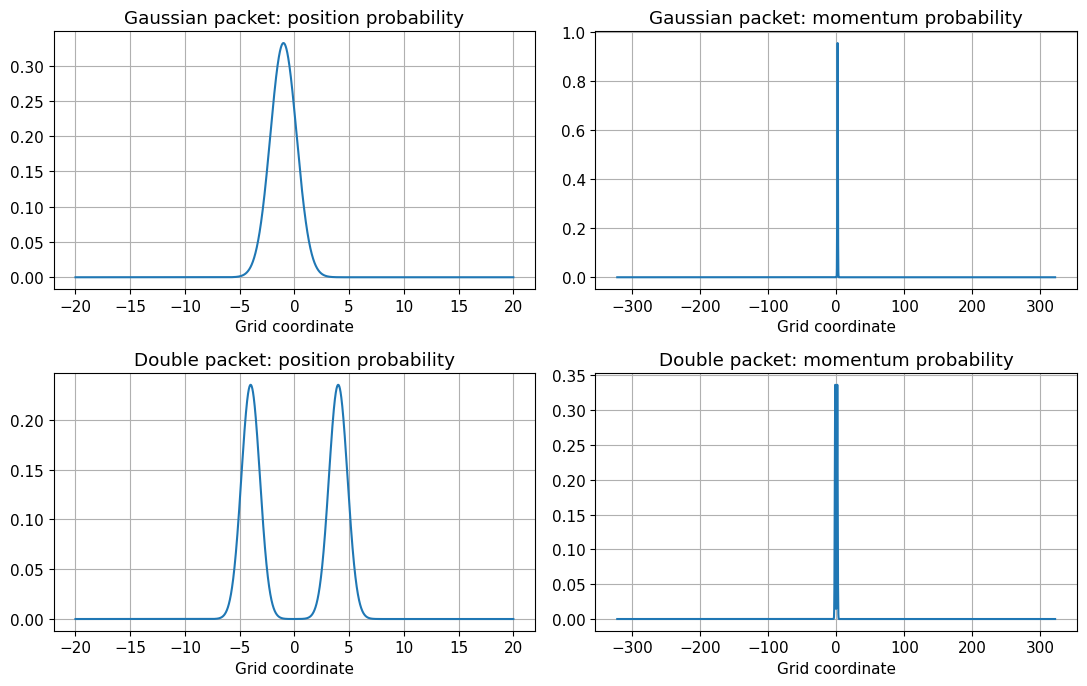

In [5]:
def psi_to_phi_k(psi_x):
    phi_k = fftc(psi_x)
    return phi_k / np.sqrt(np.trapezoid(np.abs(phi_k)**2, k_grid))

phi_gauss = psi_to_phi_k(psi_gauss)
phi_double = psi_to_phi_k(psi_double)

Px_gauss = normalize_density(probability_density(psi_gauss), x_grid)
Pk_gauss = normalize_density(probability_density(phi_gauss), k_grid)

Px_double = normalize_density(probability_density(psi_double), x_grid)
Pk_double = normalize_density(probability_density(phi_double), k_grid)

fig, axs = plt.subplots(2, 2, figsize=(11, 7))
axs[0, 0].plot(x_grid, Px_gauss)
axs[0, 0].set_title("Gaussian packet: position probability")
axs[0, 1].plot(k_grid, Pk_gauss)
axs[0, 1].set_title("Gaussian packet: momentum probability")
axs[1, 0].plot(x_grid, Px_double)
axs[1, 0].set_title("Double packet: position probability")
axs[1, 1].plot(k_grid, Pk_double)
axs[1, 1].set_title("Double packet: momentum probability")
for ax in axs.ravel():
    ax.set_xlabel("Grid coordinate")
plt.tight_layout()
plt.show()


## Part D — Expectation values


In [6]:
def expectation_x(psi, x):
    return float(np.real(np.trapezoid(np.conjugate(psi) * x * psi, x)))

def expectation_p(psi, x, hbar=1.0):
    dpsi_dx = np.gradient(psi, x)
    ppsi = -1j * hbar * dpsi_dx
    return float(np.real(np.trapezoid(np.conjugate(psi) * ppsi, x)))

def variance_x(psi, x):
    ex = expectation_x(psi, x)
    return float(np.real(np.trapezoid(np.conjugate(psi) * (x - ex)**2 * psi, x)))

def variance_p(psi, x, hbar=1.0):
    ep = expectation_p(psi, x, hbar=hbar)
    dpsi_dx = np.gradient(psi, x)
    d2psi_dx2 = np.gradient(dpsi_dx, x)
    p2psi = -(hbar**2) * d2psi_dx2
    exp_p2 = np.real(np.trapezoid(np.conjugate(psi) * p2psi, x))
    return float(exp_p2 - ep**2)

for name, psi in [("Gaussian", psi_gauss), ("Double", psi_double)]:
    ex = expectation_x(psi, x_grid)
    ep = expectation_p(psi, x_grid, hbar=HBAR)
    vx = variance_x(psi, x_grid)
    vp = variance_p(psi, x_grid, hbar=HBAR)
    print(f"{name} state:")
    print("  <x> =", ex)
    print("  <p> =", ep)
    print("  Var(x) =", vx)
    print("  Var(p) =", vp)
    print("  uncertainty product ~", np.sqrt(max(vx,0)) * np.sqrt(max(vp,0)))


Gaussian state:
  <x> = -0.9999999999999998
  <p> = 1.9998562772443473
  Var(x) = 1.4449999999999998
  Var(p) = 0.1729415042400797
  uncertainty product ~ 0.49990046371944397
Double state:
  <x> = 1.0949036186591599e-06
  <p> = 1.4082045169949708e-06
  Var(x) = 16.719993952030148
  Var(p) = 2.5968977267506412
  uncertainty product ~ 6.589394075733485


## Part E — Quantum inverse problem


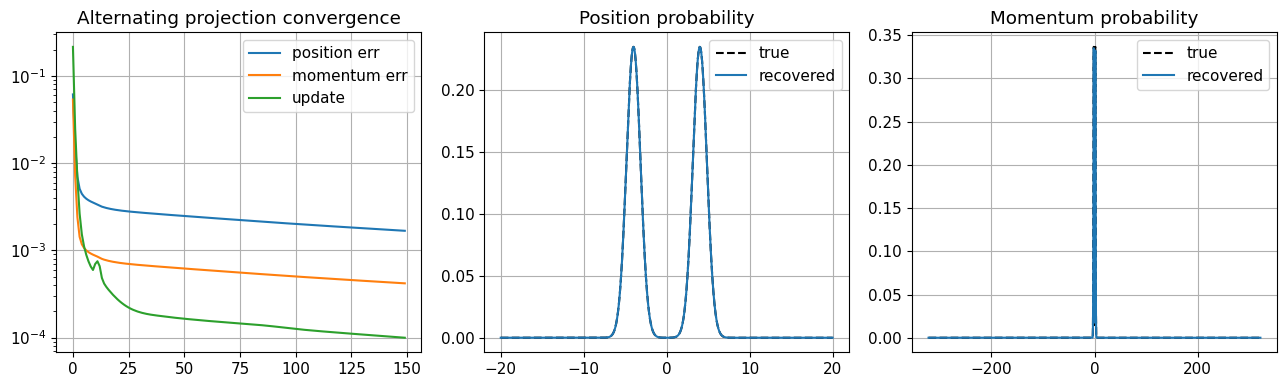

In [7]:
def quantum_alternating_projection(Px_meas, Pk_meas, n_iter=120, seed=0):
    rng_local = np.random.default_rng(seed)

    mag_x = np.sqrt(np.maximum(Px_meas, 0.0))
    mag_k = np.sqrt(np.maximum(Pk_meas, 0.0))

    phase0 = rng_local.uniform(-np.pi, np.pi, size=mag_x.shape)
    psi = mag_x * np.exp(1j * phase0)
    psi = normalize_wavefunction(psi, x_grid)

    history = {"err_x": [], "err_k": [], "update": []}
    prev = psi.copy()

    for _ in range(n_iter):
        phi = psi_to_phi_k(psi)
        err_k = np.sqrt(np.mean((np.abs(phi) - mag_k) ** 2))
        phi = mag_k * np.exp(1j * np.angle(phi))

        psi = ifftc(phi)
        psi = normalize_wavefunction(psi, x_grid)
        err_x = np.sqrt(np.mean((np.abs(psi) - mag_x) ** 2))
        psi = mag_x * np.exp(1j * np.angle(psi))
        psi = normalize_wavefunction(psi, x_grid)

        upd = np.sqrt(np.mean(np.abs(psi - prev) ** 2))
        prev = psi.copy()

        history["err_x"].append(err_x)
        history["err_k"].append(err_k)
        history["update"].append(upd)

    return psi, history

psi_ap, hist_ap = quantum_alternating_projection(Px_double, Pk_double, n_iter=150, seed=1)
Px_ap = normalize_density(probability_density(psi_ap), x_grid)
Pk_ap = normalize_density(probability_density(psi_to_phi_k(psi_ap)), k_grid)

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].plot(hist_ap["err_x"], label="position err")
axs[0].plot(hist_ap["err_k"], label="momentum err")
axs[0].plot(hist_ap["update"], label="update")
axs[0].set_yscale("log")
axs[0].set_title("Alternating projection convergence")
axs[0].legend()

axs[1].plot(x_grid, Px_double, "k--", label="true")
axs[1].plot(x_grid, Px_ap, label="recovered")
axs[1].set_title("Position probability")
axs[1].legend()

axs[2].plot(k_grid, Pk_double, "k--", label="true")
axs[2].plot(k_grid, Pk_ap, label="recovered")
axs[2].set_title("Momentum probability")
axs[2].legend()

plt.tight_layout()
plt.show()


## Part F — Small AI inverse model


In [8]:
feature_len = 256
latent_len = 256

def downsample_1d(x, new_len):
    idx = np.linspace(0, len(x) - 1, new_len)
    return np.interp(idx, np.arange(len(x)), np.asarray(x, dtype=float))

def compact_to_full(x_compact, full_len):
    return np.interp(
        np.linspace(0, len(x_compact) - 1, full_len),
        np.arange(len(x_compact)),
        np.asarray(x_compact, dtype=float)
    )

def random_quantum_state(rng_local):
    if rng_local.random() < 0.5:
        x0 = rng_local.uniform(-4.0, 4.0)
        sigma = rng_local.uniform(1.0, 2.5)
        k0 = rng_local.uniform(-3.0, 3.0)
        psi = gaussian_wavepacket(x_grid, x0=x0, sigma=sigma, k0=k0)
    else:
        x1 = rng_local.uniform(-6.0, -1.0)
        x2 = rng_local.uniform(1.0, 6.0)
        sigma = rng_local.uniform(0.8, 2.0)
        k1 = rng_local.uniform(-2.5, 2.5)
        k2 = rng_local.uniform(-2.5, 2.5)
        rel_phase = rng_local.uniform(-np.pi, np.pi)
        psi = double_gaussian_superposition(x_grid, x1=x1, x2=x2, sigma=sigma, k1=k1, k2=k2, rel_phase=rel_phase)
    return normalize_wavefunction(psi, x_grid)

def build_quantum_dataset(n_samples=240, seed=7):
    rng_local = np.random.default_rng(seed)
    X = []
    Y_amp = []
    Y_phase = []
    for _ in range(n_samples):
        psi = random_quantum_state(rng_local)
        phi = psi_to_phi_k(psi)

        Px = normalize_density(probability_density(psi), x_grid)
        Pk = normalize_density(probability_density(phi), k_grid)

        feat = np.concatenate([downsample_1d(Px, feature_len), downsample_1d(Pk, feature_len)])
        amp = downsample_1d(np.abs(psi), latent_len)
        phase = downsample_1d(np.angle(psi), latent_len)

        X.append(feat)
        Y_amp.append(amp)
        Y_phase.append(phase)

    return np.asarray(X), np.asarray(Y_amp), np.asarray(Y_phase)

Xq, Yq_amp, Yq_phase = build_quantum_dataset(n_samples=240, seed=GLOBAL_SEED)
Xq_train, Xq_test = Xq[:200], Xq[200:]
Yq_amp_train, Yq_amp_test = Yq_amp[:200], Yq_amp[200:]
Yq_phase_train, Yq_phase_test = Yq_phase[:200], Yq_phase[200:]

print("Quantum dataset shapes:", Xq.shape, Yq_amp.shape, Yq_phase.shape)


Quantum dataset shapes: (240, 512) (240, 256) (240, 256)


Linear quantum inverse RMSE amp: 0.020186835430231153
Linear quantum inverse RMSE phase: 1.9258606899411006
Quantum MLP inverse RMSE: 1.4771946668624878


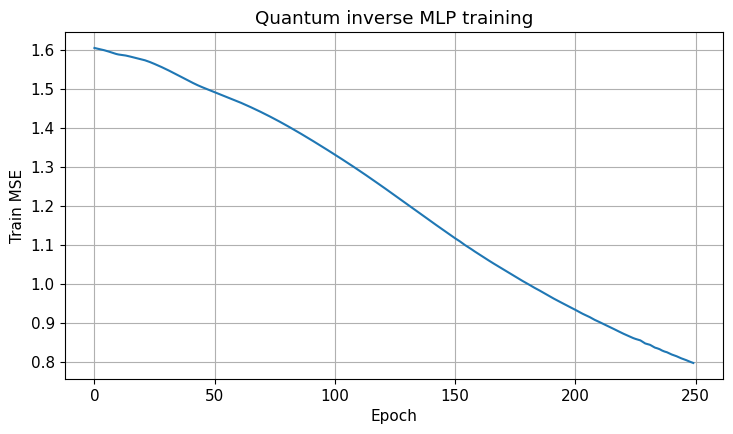

In [9]:
def fit_linear_ridge(X, Y, reg=1e-3):
    Xb = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
    I = np.eye(Xb.shape[1])
    return np.linalg.solve(Xb.T @ Xb + reg * I, Xb.T @ Y)

def predict_linear_ridge(X, W):
    Xb = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
    return Xb @ W

W_amp = fit_linear_ridge(Xq_train, Yq_amp_train, reg=1e-2)
W_phase = fit_linear_ridge(Xq_train, Yq_phase_train, reg=1e-2)

amp_pred_lin = predict_linear_ridge(Xq_test, W_amp)
phase_pred_lin = predict_linear_ridge(Xq_test, W_phase)

lin_quantum_rmse_amp = float(np.sqrt(np.mean((amp_pred_lin - Yq_amp_test) ** 2)))
lin_quantum_rmse_phase = float(np.sqrt(np.mean((phase_pred_lin - Yq_phase_test) ** 2)))
print("Linear quantum inverse RMSE amp:", lin_quantum_rmse_amp)
print("Linear quantum inverse RMSE phase:", lin_quantum_rmse_phase)

quantum_mlp = None
mlp_quantum_result = None

if TORCH_AVAILABLE:
    torch.manual_seed(GLOBAL_SEED)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    class QuantumMLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 256),
                nn.ReLU(),
                nn.Linear(256, 256),
                nn.ReLU(),
                nn.Linear(256, out_dim),
            )

        def forward(self, x):
            return self.net(x)

    Xtr = torch.tensor(Xq_train, dtype=torch.float32, device=device)
    Ytr = torch.tensor(np.concatenate([Yq_amp_train, Yq_phase_train], axis=1), dtype=torch.float32, device=device)
    Xte = torch.tensor(Xq_test, dtype=torch.float32, device=device)
    Yte = torch.tensor(np.concatenate([Yq_amp_test, Yq_phase_test], axis=1), dtype=torch.float32, device=device)

    quantum_mlp = QuantumMLP(Xq_train.shape[1], 2 * latent_len).to(device)
    opt = torch.optim.Adam(quantum_mlp.parameters(), lr=1e-3)

    hist = []
    for epoch in range(250):
        opt.zero_grad()
        pred = quantum_mlp(Xtr)
        loss = F.mse_loss(pred, Ytr)
        loss.backward()
        opt.step()
        hist.append(float(loss.item()))

    with torch.no_grad():
        pred_test = quantum_mlp(Xte)
        test_rmse = float(torch.sqrt(torch.mean((pred_test - Yte) ** 2)).item())

    mlp_quantum_result = {"test_rmse": test_rmse, "history": hist, "device": device}
    print("Quantum MLP inverse RMSE:", test_rmse)

    fig, ax = plt.subplots()
    ax.plot(hist)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train MSE")
    ax.set_title("Quantum inverse MLP training")
    plt.show()
else:
    print("Torch not available; skipping quantum MLP.")


## Part G — PINN-style quantum reconstruction


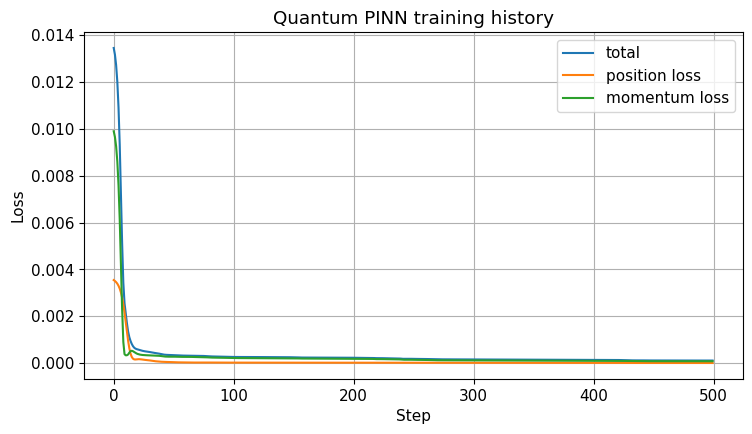

In [10]:
quantum_pinn_result = None

if TORCH_AVAILABLE:
    torch.manual_seed(GLOBAL_SEED)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.set_default_dtype(torch.float64)

    def ttorch(x):
        return torch.as_tensor(x, device=device, dtype=torch.float64)

    x_t = ttorch(x_grid)
    k_t = ttorch(k_grid)
    Px_meas_t = ttorch(Px_double)
    Pk_meas_t = ttorch(Pk_double)
    feat_t = ttorch(np.concatenate([downsample_1d(Px_double, feature_len), downsample_1d(Pk_double, feature_len)])).unsqueeze(0)

    def normalize_density_torch(rho, grid):
        area = torch.trapz(torch.clamp(rho.real, min=0.0), grid)
        return torch.clamp(rho.real, min=0.0) / torch.clamp(area, min=1e-14)

    def interp_linear_torch(x_compact, full_len):
        x = x_compact.view(1, 1, -1)
        y = F.interpolate(x, size=full_len, mode="linear", align_corners=True)
        return y.view(-1)

    def fftc_torch(x):
        return torch.fft.fftshift(torch.fft.fft(torch.fft.ifftshift(x)))

    class QuantumPINN(nn.Module):
        def __init__(self, in_dim, latent_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 256),
                nn.Tanh(),
                nn.Linear(256, 256),
                nn.Tanh(),
                nn.Linear(256, 2 * latent_dim),
            )
            self.latent_dim = latent_dim

        def forward(self, x):
            out = self.net(x)
            amp_raw = out[..., :self.latent_dim]
            phase_raw = out[..., self.latent_dim:]
            amp = F.softplus(amp_raw)
            phase = np.pi * torch.tanh(phase_raw)
            return amp, phase

    def total_variation_torch(x):
        return torch.mean(torch.abs(x[1:] - x[:-1]))

    model = QuantumPINN(in_dim=feat_t.shape[1], latent_dim=latent_len).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    hist = {"loss": [], "pos": [], "mom": [], "tv_amp": [], "tv_phase": []}

    for step in range(500):
        opt.zero_grad()

        amp_latent, phase_latent = model(feat_t)
        amp_full = interp_linear_torch(amp_latent.view(-1), len(x_grid))
        phase_full = interp_linear_torch(phase_latent.view(-1), len(x_grid))

        psi_pred = amp_full * torch.exp(1j * phase_full)
        norm = torch.sqrt(torch.trapz(torch.abs(psi_pred) ** 2, x_t))
        psi_pred = psi_pred / torch.clamp(norm, min=1e-14)

        phi_pred = fftc_torch(psi_pred)

        Px_pred = normalize_density_torch(torch.abs(psi_pred) ** 2, x_t)
        Pk_pred = normalize_density_torch(torch.abs(phi_pred) ** 2, k_t)

        loss_pos = F.mse_loss(Px_pred, Px_meas_t)
        loss_mom = F.mse_loss(Pk_pred, Pk_meas_t)
        loss_tv_amp = total_variation_torch(amp_full)
        loss_tv_phase = total_variation_torch(phase_full)

        loss = loss_pos + loss_mom + 1e-3 * loss_tv_amp + 1e-4 * loss_tv_phase
        loss.backward()
        opt.step()

        hist["loss"].append(float(loss.item()))
        hist["pos"].append(float(loss_pos.item()))
        hist["mom"].append(float(loss_mom.item()))
        hist["tv_amp"].append(float(loss_tv_amp.item()))
        hist["tv_phase"].append(float(loss_tv_phase.item()))

    with torch.no_grad():
        amp_latent, phase_latent = model(feat_t)
        amp_full = interp_linear_torch(amp_latent.view(-1), len(x_grid))
        phase_full = interp_linear_torch(phase_latent.view(-1), len(x_grid))
        psi_pred = amp_full * torch.exp(1j * phase_full)
        psi_pred = psi_pred / torch.sqrt(torch.trapz(torch.abs(psi_pred) ** 2, x_t))
        phi_pred = fftc_torch(psi_pred)

        Px_pred = normalize_density_torch(torch.abs(psi_pred) ** 2, x_t)
        Pk_pred = normalize_density_torch(torch.abs(phi_pred) ** 2, k_t)

    quantum_pinn_result = {
        "history": hist,
        "Px_pred": Px_pred.detach().cpu().numpy(),
        "Pk_pred": Pk_pred.detach().cpu().numpy(),
        "psi_pred_real": np.real(psi_pred.detach().cpu().numpy()),
        "psi_pred_imag": np.imag(psi_pred.detach().cpu().numpy()),
    }

    fig, ax = plt.subplots()
    ax.plot(hist["loss"], label="total")
    ax.plot(hist["pos"], label="position loss")
    ax.plot(hist["mom"], label="momentum loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.set_title("Quantum PINN training history")
    ax.legend()
    plt.show()
else:
    print("Torch not available; skipping quantum PINN.")


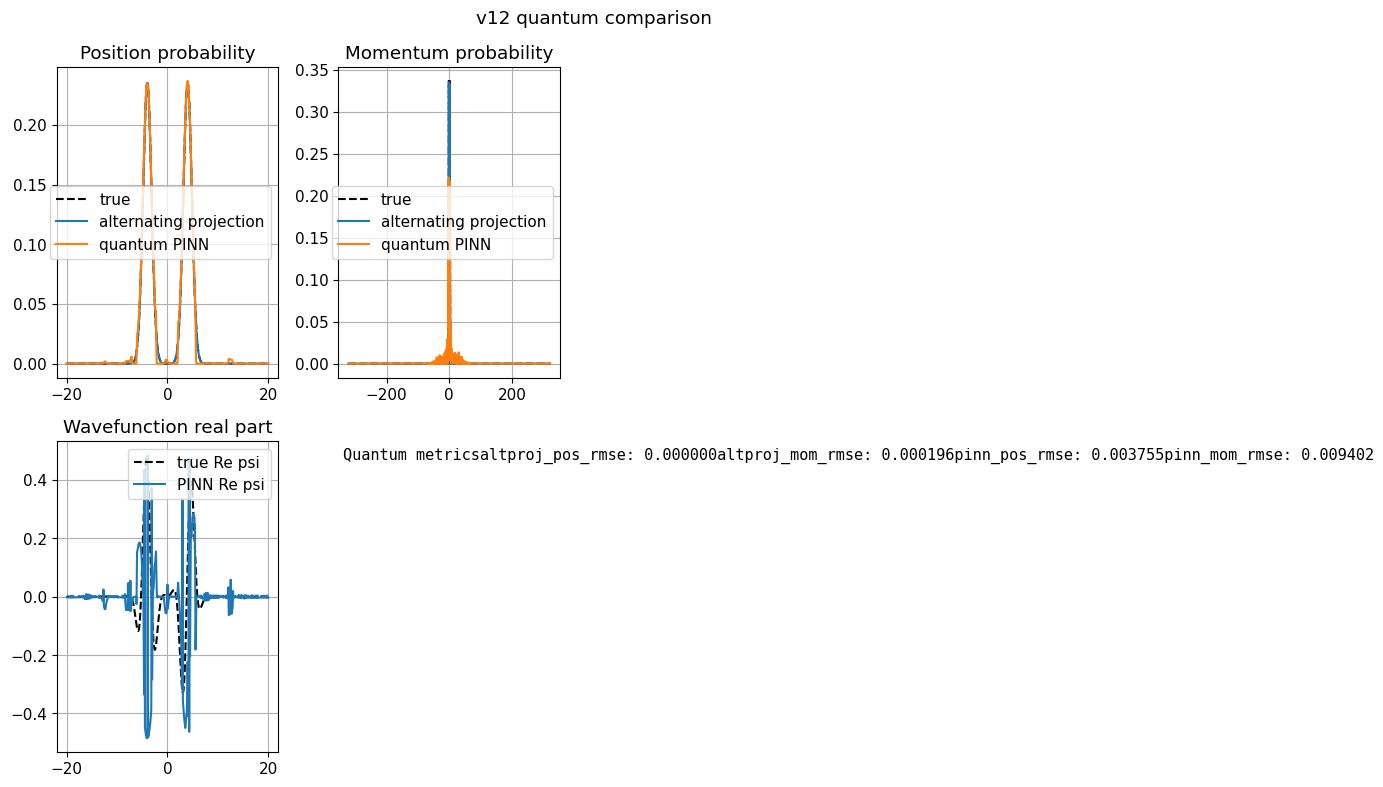

Metrics: {'altproj_pos_rmse': np.float64(1.184550855366441e-17), 'altproj_mom_rmse': np.float64(0.0001956171915821712), 'pinn_pos_rmse': np.float64(0.0037545721312059414), 'pinn_mom_rmse': np.float64(0.0094019680153018)}


In [13]:
import numpy as np

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
    
metrics = {
    "altproj_pos_rmse": rmse(Px_double, Px_ap),
    "altproj_mom_rmse": rmse(Pk_double, Pk_ap),
}
if quantum_pinn_result is not None:
    metrics["pinn_pos_rmse"] = rmse(Px_double, quantum_pinn_result["Px_pred"])
    metrics["pinn_mom_rmse"] = rmse(Pk_double, quantum_pinn_result["Pk_pred"])

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(x_grid, Px_double, "k--", label="true")
axs[0, 0].plot(x_grid, Px_ap, label="alternating projection")
if quantum_pinn_result is not None:
    axs[0, 0].plot(x_grid, quantum_pinn_result["Px_pred"], label="quantum PINN")
axs[0, 0].set_title("Position probability")
axs[0, 0].legend()

axs[0, 1].plot(k_grid, Pk_double, "k--", label="true")
axs[0, 1].plot(k_grid, Pk_ap, label="alternating projection")
if quantum_pinn_result is not None:
    axs[0, 1].plot(k_grid, quantum_pinn_result["Pk_pred"], label="quantum PINN")
axs[0, 1].set_title("Momentum probability")
axs[0, 1].legend()

axs[1, 0].plot(x_grid, np.real(psi_double), "k--", label="true Re psi")
if quantum_pinn_result is not None:
    axs[1, 0].plot(x_grid, quantum_pinn_result["psi_pred_real"], label="PINN Re psi")
axs[1, 0].set_title("Wavefunction real part")
axs[1, 0].legend()

axs[1, 1].axis("off")
lines = [f"{k}: {v:.6f}" for k, v in metrics.items()]
axs[1, 1].text(0.02, 0.98, "Quantum metrics" + "".join(lines), va="top", family="monospace", fontsize=11)

fig.suptitle("v12 quantum comparison")
plt.tight_layout()
plt.show()

print("Metrics:", metrics)


## Physical interpretation

This notebook mirrors the optics project exactly:

### Optics
$
I = |E|^2
$

### Quantum mechanics
$
P = |\psi|^2
$
In both cases:
- the hidden object is complex
- the measurement is magnitude-squared
- phase is not directly visible
- reconstruction is an inverse problem


In [ ]:
summary = {
    "torch_available": TORCH_AVAILABLE,
    "has_quantum_pinn_result": quantum_pinn_result is not None,
    "linear_quantum_rmse_amp": lin_quantum_rmse_amp,
    "linear_quantum_rmse_phase": lin_quantum_rmse_phase,
    "metrics": metrics,
}
if mlp_quantum_result is not None:
    summary["mlp_quantum_inverse_rmse"] = mlp_quantum_result["test_rmse"]

out_dir = Path("/mnt/data/phase_recovery_v12_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

summary_path = out_dir / "phase_recovery_v12_summary.json"
with summary_path.open("w", encoding="utf-8") as fjson:
    json.dump(summary, fjson, indent=2)

print("Saved summary to:", summary_path)


## Suggested commit message

```text
feat: add v12 quantum wavefunction notebook for probability, measurement, and AI

- connect optics intensity |E|^2 to quantum probability density |psi|^2
- add symbolic quantum formalism with SymPy
- add numerical position-space and momentum-space wavefunctions
- add expectation value and uncertainty calculations
- add alternating-projection baseline for quantum phase retrieval
- add small AI inverse model and PINN-style quantum reconstruction
- save summary metrics for reproducibility
```
